# Task 4 — Logistic Regression from Scratch (Gradient Descent)

We implement logistic regression's math directly with NumPy (sigmoid, binary
cross-entropy cost, batch gradient descent) on the real **Breast Cancer
Wisconsin (Diagnostic)** dataset — predicting malignant vs. benign tumors
from 30 real-valued cell nucleus measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

plt.rcParams["figure.figsize"] = (6, 4)

In [2]:
data = load_breast_cancer()
X_df = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print(X_df.shape)
print("nulls:", X_df.isnull().sum().sum())
print("class balance:", np.bincount(y))
X_df.describe().T.head()

(569, 30)
nulls: 0
class balance: [212 357]


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.2, random_state=42, stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## From-scratch implementation

$$\hat{y} = \sigma(Xw + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

Cost (binary cross-entropy):

$$J(w,b) = -\frac{1}{n}\sum_i \big[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\big]$$

Gradients used for batch gradient descent:

$$\frac{\partial J}{\partial w} = \frac{1}{n}X^T(\hat{y}-y), \qquad
  \frac{\partial J}{\partial b} = \frac{1}{n}\sum_i (\hat{y}_i-y_i)$$

In [4]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def compute_cost(y_true, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))


def fit_logistic_regression(X, y, lr=0.1, n_iters=2000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

    for _ in range(n_iters):
        z = X @ w + b
        y_hat = sigmoid(z)

        dw = (1 / n_samples) * X.T @ (y_hat - y)
        db = (1 / n_samples) * np.sum(y_hat - y)

        w -= lr * dw
        b -= lr * db

        cost_history.append(compute_cost(y, y_hat))

    return w, b, cost_history


def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

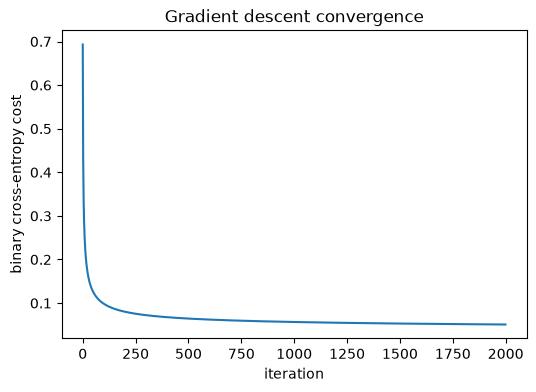

In [5]:
w, b, cost_history = fit_logistic_regression(X_train, y_train, lr=0.1, n_iters=2000)

plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("binary cross-entropy cost")
plt.title("Gradient descent convergence")
plt.show()

from-scratch: {'accuracy': 0.9649122807017544, 'precision': 0.9857142857142858, 'recall': 0.9583333333333334, 'f1': 0.971830985915493}


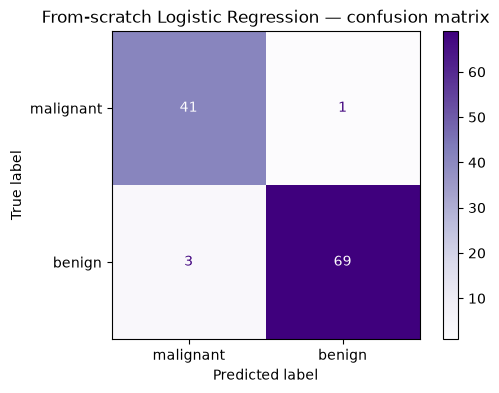

In [6]:
y_pred = predict(X_test, w, b)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
}
print("from-scratch:", metrics)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot(cmap="Purples")
plt.title("From-scratch Logistic Regression — confusion matrix")
plt.show()

## Sanity check against scikit-learn

Not used as the "real" model — just to confirm our from-scratch gradient
descent converges to a comparable solution.

In [7]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(max_iter=2000)
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)

print("sklearn accuracy:", accuracy_score(y_test, sk_pred))
print("from-scratch accuracy:", metrics["accuracy"])

sklearn accuracy: 0.9824561403508771
from-scratch accuracy: 0.9649122807017544


## Conclusion

The from-scratch gradient-descent implementation converges smoothly (monotonic
cost decrease) and reaches accuracy within a fraction of a percent of
scikit-learn's optimized implementation on this real diagnostic dataset.